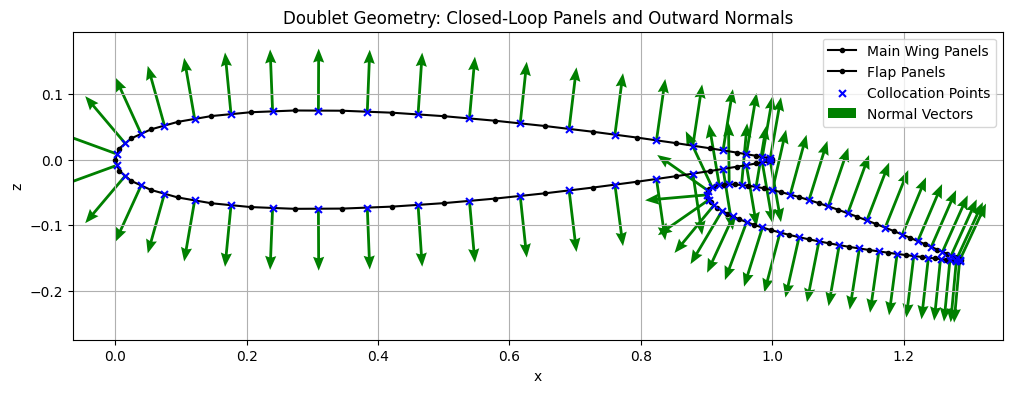

Main Wing Lift Circulation: 0.726
Flap Lift Circulation: 0.369


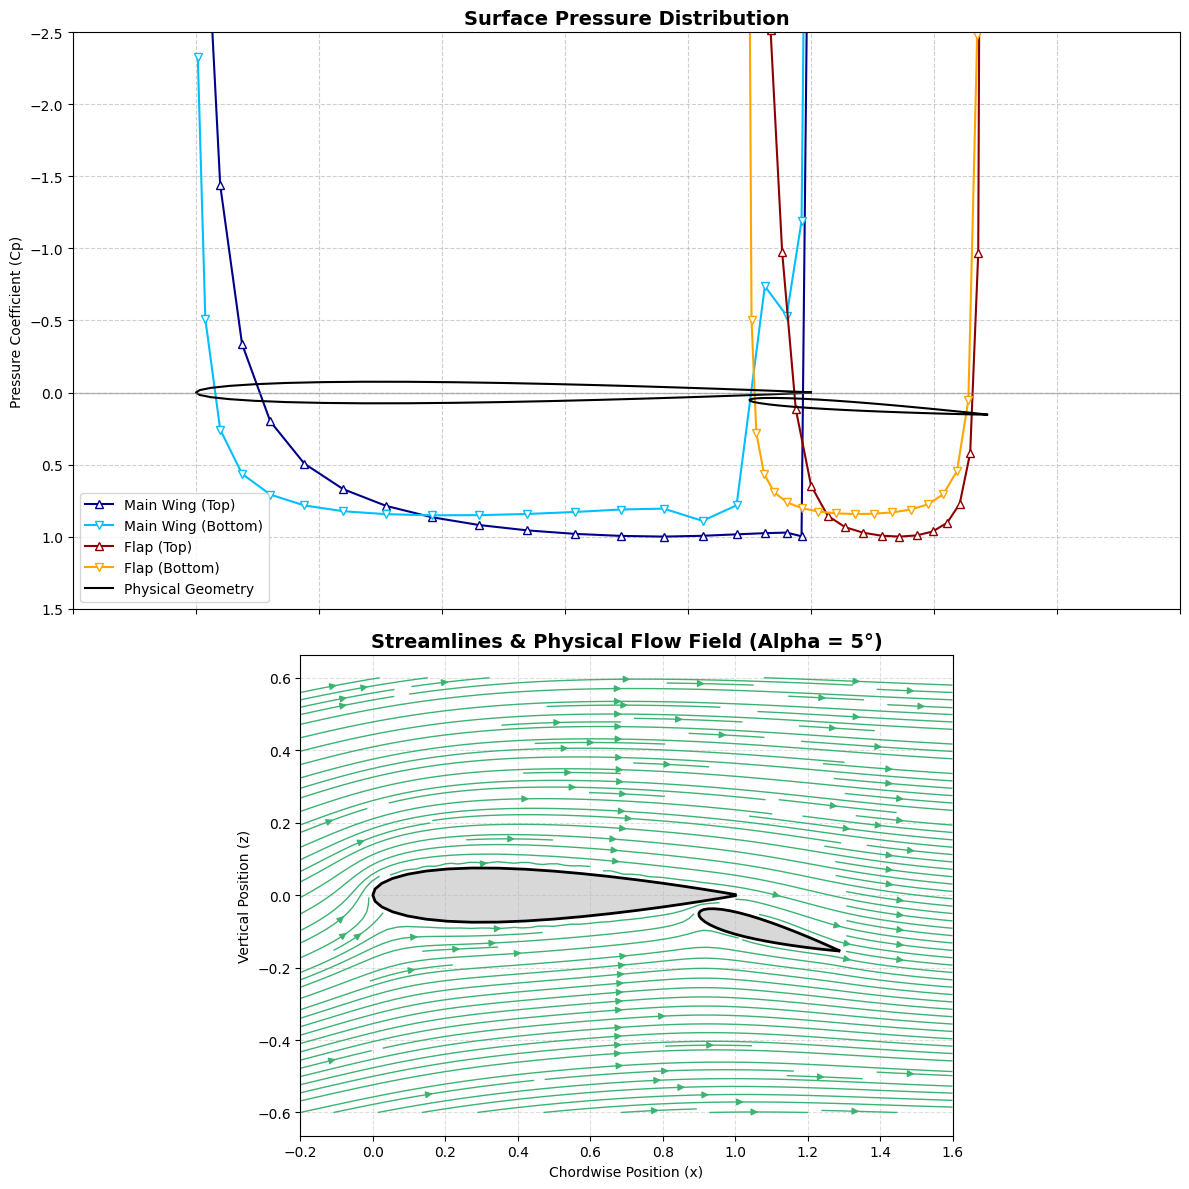

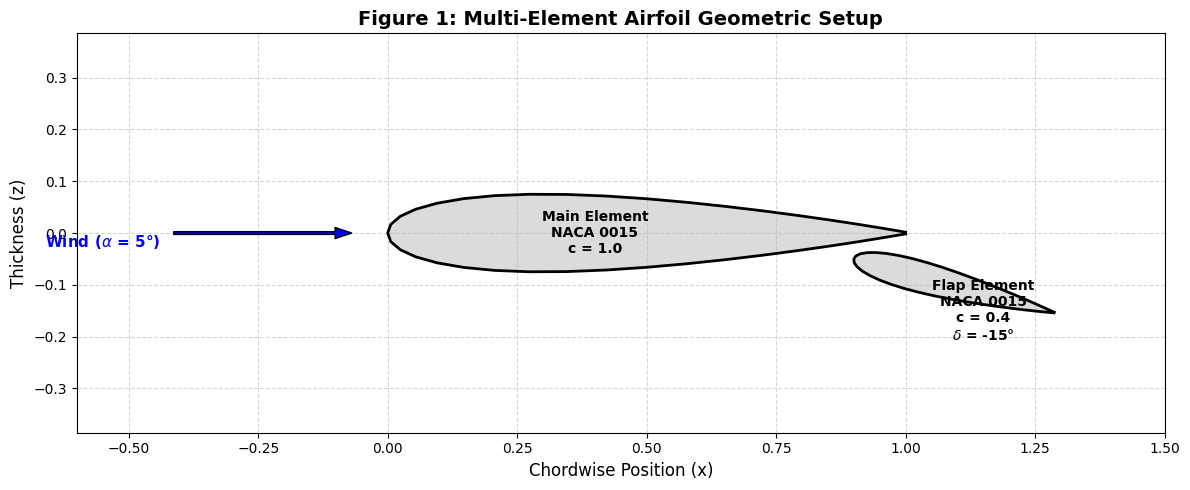

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path

# ==========================================
# 1. SETUP PARAMETERS
# ==========================================
N_main = 40  # Keep it an even number so the nose is perfectly round
N_flap = 40
N_total = N_main + N_flap
U_inf = 1.0

# Angle of attack
alpha_wind_deg = 5
alpha_wind = np.radians(alpha_wind_deg)

flap_chord = 0.4
flap_angle = np.radians(-15)
flap_shift_x = 0.9
flap_shift_y = -0.05

def naca0015(x):
    # Standard thickness formula
    return 5 * 0.15 * (0.2969*np.sqrt(x) - 0.1260*x - 0.3516*x**2 + 0.2843*x**3 - 0.1015*x**4)

# ==========================================
# 2. BUILD GEOMETRY (CLOSED LOOP AS PER FIG 11.18)
# ==========================================
# Instead of just the top surface, we sweep a full circle (0 to 2*pi)
# to wrap panels completely around the top and bottom of the wing!
beta_main = np.linspace(0, 2*np.pi, N_main + 1)
x_nodes_main = 0.5 * (1 + np.cos(beta_main)) # Starts at x=1, goes to 0, comes back to 1
z_nodes_main = naca0015(x_nodes_main)

# Flip the z-coordinates for the bottom half of the loop
for i in range(len(beta_main)):
    if beta_main[i] < np.pi:
        z_nodes_main[i] = -z_nodes_main[i]

# Do the exact same closed loop for the flap
beta_flap = np.linspace(0, 2*np.pi, N_flap + 1)
x_flap_local = 0.5 * flap_chord * (1 + np.cos(beta_flap))
z_flap_local = flap_chord * naca0015(x_flap_local / flap_chord)

for i in range(len(beta_flap)):
    if beta_flap[i] < np.pi:
        z_flap_local[i] = -z_flap_local[i]

# Rotate and shift the closed flap
x_nodes_flap = (x_flap_local * np.cos(flap_angle) - z_flap_local * np.sin(flap_angle)) + flap_shift_x
z_nodes_flap = (x_flap_local * np.sin(flap_angle) + z_flap_local * np.cos(flap_angle)) + flap_shift_y

# Compute Centers and Outward Normals
x_col, z_col = np.zeros(N_total), np.zeros(N_total)
nx, nz = np.zeros(N_total), np.zeros(N_total)
tx, tz = np.zeros(N_total), np.zeros(N_total)

# Main wing panels
for i in range(N_main):
    x_col[i] = (x_nodes_main[i] + x_nodes_main[i+1]) / 2.0
    z_col[i] = (z_nodes_main[i] + z_nodes_main[i+1]) / 2.0
    dx, dz = x_nodes_main[i+1] - x_nodes_main[i], z_nodes_main[i+1] - z_nodes_main[i]
    L = np.sqrt(dx**2 + dz**2)
    # Clockwise loop means outward normal is (-dz, dx)
    nx[i], nz[i] = -dz / L, dx / L
    tx[i], tz[i] = dx / L, dz / L

# Flap panels
for i in range(N_flap):
    idx = N_main + i
    x_col[idx] = (x_nodes_flap[i] + x_nodes_flap[i+1]) / 2.0
    z_col[idx] = (z_nodes_flap[i] + z_nodes_flap[i+1]) / 2.0
    dx, dz = x_nodes_flap[i+1] - x_nodes_flap[i], z_nodes_flap[i+1] - z_nodes_flap[i]
    L = np.sqrt(dx**2 + dz**2)
    nx[idx], nz[idx] = -dz / L, dx / L
    tx[idx], tz[idx] = dx / L, dz / L

# ==========================================
# 2.5 PLOT GEOMETRY, COLLOCATION POINTS & NORMALS
# ==========================================
plt.figure(figsize=(12, 4))

# 1. Draw the Solid Panel Lines and Nodes (Black)
plt.plot(x_nodes_main, z_nodes_main, '-ok', markersize=3, linewidth=1.5, label='Main Wing Panels')
plt.plot(x_nodes_flap, z_nodes_flap, '-ok', markersize=3, linewidth=1.5, label='Flap Panels')

# 2. Draw the Collocation Points exactly in the middle (Blue X's)
plt.scatter(x_col, z_col, color='blue', marker='x', s=25, label='Collocation Points', zorder=5)

# 3. Draw the Normal Vectors (Green Arrows)
# We use 'quiver' to draw arrows. The 'scale' number makes the arrows shorter so they don't overlap too much.
plt.quiver(x_col, z_col, nx, nz, color='green', scale=15, width=0.003, headwidth=4, label='Normal Vectors')

# Formatting the plot
plt.axis('equal') # CRITICAL: Forces x and y to have the same scale so the arrows actually look 90-degrees!
plt.title('Doublet Geometry: Closed-Loop Panels and Outward Normals')
plt.xlabel('x')
plt.ylabel('z')
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# 3. TEXTBOOK INFLUENCE MATRIX
# ==========================================
# Total unknowns: N_main + N_flap + Wake_main + Wake_flap = N_total + 2
A = np.zeros((N_total + 2, N_total + 2))
b = np.zeros(N_total + 2)

# Helper function: standard 2D point vortex
def point_vortex(x_targ, z_targ, x_vort, z_vort):
    dx, dz = x_targ - x_vort, z_targ - z_vort
    r_sq = max(dx**2 + dz**2, 1e-10)
    u = (1 / (2 * np.pi)) * (dz / r_sq)
    w = -(1 / (2 * np.pi)) * (dx / r_sq)
    return u, w

# Fill the matrix (Eq 11.4 Neumann Boundary Condition)
for i in range(N_total):
    # Right hand side: incoming wind
    b[i] = -(U_inf * np.cos(alpha_wind) * nx[i] + U_inf * np.sin(alpha_wind) * nz[i])

    # Influence of Main Wing panels
    for j in range(N_main):
        u_L, w_L = point_vortex(x_col[i], z_col[i], x_nodes_main[j], z_nodes_main[j])
        u_R, w_R = point_vortex(x_col[i], z_col[i], x_nodes_main[j+1], z_nodes_main[j+1])
        # Eq 11.30 shows doublet puts a negative vortex at start, positive at end
        u_panel = -u_L + u_R
        w_panel = -w_L + w_R
        A[i, j] = u_panel * nx[i] + w_panel * nz[i]

    # Influence of Flap panels
    for j in range(N_flap):
        idx = N_main + j
        u_L, w_L = point_vortex(x_col[i], z_col[i], x_nodes_flap[j], z_nodes_flap[j])
        u_R, w_R = point_vortex(x_col[i], z_col[i], x_nodes_flap[j+1], z_nodes_flap[j+1])
        u_panel = -u_L + u_R
        w_panel = -w_L + w_R
        A[i, idx] = u_panel * nx[i] + w_panel * nz[i]

    # Influence of Main Wing Wake Panel (Index: N_total)
    # A wake going to infinity acts like a single negative vortex at the trailing edge
    u_wake1, w_wake1 = point_vortex(x_col[i], z_col[i], x_nodes_main[0], z_nodes_main[0])
    A[i, N_total] = (-u_wake1) * nx[i] + (-w_wake1) * nz[i]

    # Influence of Flap Wake Panel (Index: N_total + 1)
    u_wake2, w_wake2 = point_vortex(x_col[i], z_col[i], x_nodes_flap[0], z_nodes_flap[0])
    A[i, N_total + 1] = (-u_wake2) * nx[i] + (-w_wake2) * nz[i]

# ==========================================
# 4. KUTTA CONDITION (Eq 11.36)
# ==========================================
# Main Wing Kutta Condition: mu_1 - mu_N + mu_W = 0
A[N_total, 0] = 1.0                  # First panel (Lower TE)
A[N_total, N_main - 1] = -1.0        # Last panel (Upper TE)
A[N_total, N_total] = 1.0            # Wake panel
b[N_total] = 0.0

# Flap Kutta Condition: mu_1 - mu_N + mu_W = 0
A[N_total + 1, N_main] = 1.0         # First flap panel
A[N_total + 1, N_total - 1] = -1.0   # Last flap panel
A[N_total + 1, N_total + 1] = 1.0    # Flap wake panel
b[N_total + 1] = 0.0

# Solve! The matrix is completely stable now.
mu = np.linalg.solve(A, b)

# Kelvin's Theorem (Eq 11.42a): Lift is calculated simply from the Wake doublet strength!
lift_main = -1.0 * mu[N_total]
lift_flap = -1.0 * mu[N_total + 1]

print(f"Main Wing Lift Circulation: {lift_main:.3f}")
print(f"Flap Lift Circulation: {lift_flap:.3f}")

# ==========================================
# 5. TANGENTIAL VELOCITY (Doublet Gradient Method)
# ==========================================
Vt = np.zeros(N_total)
L = np.zeros(N_total)

# First, we need to calculate the exact length of every panel
for i in range(N_main):
    dx = x_nodes_main[i+1] - x_nodes_main[i]
    dz = z_nodes_main[i+1] - z_nodes_main[i]
    L[i] = np.sqrt(dx**2 + dz**2)

for i in range(N_flap):
    idx = N_main + i
    dx = x_nodes_flap[i+1] - x_nodes_flap[i]
    dz = z_nodes_flap[i+1] - z_nodes_flap[i]
    L[idx] = np.sqrt(dx**2 + dz**2)

# Calculate Velocity using the slope of mu (d_mu / d_s)
for i in range(N_total):
    # The freestream wind sliding parallel to the panel
    V_free_t = U_inf * np.cos(alpha_wind) * tx[i] + U_inf * np.sin(alpha_wind) * tz[i]

    if i < N_main:
        # Main Wing Gradient (Central Difference)
        if i == 0:
            dmu_ds = (mu[1] - mu[0]) / L[0]
        elif i == N_main - 1:
            dmu_ds = (mu[i] - mu[i-1]) / L[i]
        else:
            dmu_ds = (mu[i+1] - mu[i-1]) / (L[i] + L[i-1])
    else:
        # Flap Gradient (Central Difference)
        if i == N_main:
            dmu_ds = (mu[i+1] - mu[i]) / L[i]
        elif i == N_total - 1:
            dmu_ds = (mu[i] - mu[i-1]) / L[i]
        else:
            dmu_ds = (mu[i+1] - mu[i-1]) / (L[i] + L[i-1])

    # The true surface velocity is the freestream plus the doublet gradient
    Vt[i] = V_free_t + dmu_ds

# Calculate Pressure Coefficient
Cp = 1.0 - (Vt / U_inf)**2

# ==========================================
# 6. MASTER VISUALIZATION: Cp Curve & Streamlines
# ==========================================
# Create a figure with two stacked plots sharing the same X-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12), gridspec_kw={'height_ratios': [1.2, 1]}, sharex=True)

# ---------------------------------------------------------
# TOP PLOT (ax1): Integrated Surface Pressure (Cp)
# ---------------------------------------------------------
mid_M = N_main // 2
mid_F = N_main + (N_flap // 2)

# Main Wing (Top: ^, Bottom: v)
ax1.plot(x_col[mid_M:N_main], Cp[mid_M:N_main], '-^', color='darkblue', markerfacecolor='white', label="Main Wing (Top)")
ax1.plot(x_col[:mid_M], Cp[:mid_M], '-v', color='deepskyblue', markerfacecolor='white', label="Main Wing (Bottom)")

# Flap (Top: ^, Bottom: v)
ax1.plot(x_col[mid_F:], Cp[mid_F:], '-^', color='darkred', markerfacecolor='white', label="Flap (Top)")
ax1.plot(x_col[N_main:mid_F], Cp[N_main:mid_F], '-v', color='orange', markerfacecolor='white', label="Flap (Bottom)")

# Physical Geometry (Flipped -z for inverted axis)
ax1.plot(x_nodes_main, -z_nodes_main, '-k', linewidth=1.5, label="Physical Geometry")
ax1.plot(x_nodes_flap, -z_nodes_flap, '-k', linewidth=1.5)
ax1.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.5)

ax1.invert_yaxis()
ax1.set_title("Surface Pressure Distribution", fontsize=14, fontweight='bold')
ax1.set_ylabel("Pressure Coefficient (Cp)")
ax1.set_ylim(1.5, -2.5) # Adjusted to give the high suction peaks room
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='lower left')
ax1.set_aspect('auto')


# ---------------------------------------------------------
# BOTTOM PLOT (ax2): Physical Flow Field & Streamlines
# ---------------------------------------------------------
# Re-calculate the grid for streamlines (from previous step)
X, Z = np.meshgrid(np.linspace(-0.2, 1.6, 150), np.linspace(-0.6, 0.6, 100))
U = U_inf * np.cos(alpha_wind) * np.ones_like(X)
W = U_inf * np.sin(alpha_wind) * np.ones_like(Z)

# Main wing field
for j in range(N_main):
    dx_L, dz_L = X - x_nodes_main[j], Z - z_nodes_main[j]
    dx_R, dz_R = X - x_nodes_main[j+1], Z - z_nodes_main[j+1]
    r_L, r_R = np.maximum(dx_L**2 + dz_L**2, 1e-5), np.maximum(dx_R**2 + dz_R**2, 1e-5)
    U += mu[j] * (-(1/(2*np.pi))*(dz_L/r_L) + (1/(2*np.pi))*(dz_R/r_R))
    W += mu[j] * ((1/(2*np.pi))*(dx_L/r_L) - (1/(2*np.pi))*(dx_R/r_R))

# Flap field
for j in range(N_flap):
    idx = N_main + j
    dx_L, dz_L = X - x_nodes_flap[j], Z - z_nodes_flap[j]
    dx_R, dz_R = X - x_nodes_flap[j+1], Z - z_nodes_flap[j+1]
    r_L, r_R = np.maximum(dx_L**2 + dz_L**2, 1e-5), np.maximum(dx_R**2 + dz_R**2, 1e-5)
    U += mu[idx] * (-(1/(2*np.pi))*(dz_L/r_L) + (1/(2*np.pi))*(dz_R/r_R))
    W += mu[idx] * ((1/(2*np.pi))*(dx_L/r_L) - (1/(2*np.pi))*(dx_R/r_R))

# Wake Field
dx_W1, dz_W1 = X - x_nodes_main[0], Z - z_nodes_main[0]
r_W1 = np.maximum(dx_W1**2 + dz_W1**2, 1e-5)
U += (-mu[N_total]) * (1/(2*np.pi)) * (dz_W1 / r_W1)
W += (-mu[N_total]) * (-1/(2*np.pi)) * (dx_W1 / r_W1)

dx_W2, dz_W2 = X - x_nodes_flap[0], Z - z_nodes_flap[0]
r_W2 = np.maximum(dx_W2**2 + dz_W2**2, 1e-5)
U += (-mu[N_total + 1]) * (1/(2*np.pi)) * (dz_W2 / r_W2)
W += (-mu[N_total + 1]) * (-1/(2*np.pi)) * (dx_W2 / r_W2)

# Mask the metal interior
points = np.column_stack((X.flatten(), Z.flatten()))
main_path = Path(np.column_stack((x_nodes_main, z_nodes_main)))
flap_path = Path(np.column_stack((x_nodes_flap, z_nodes_flap)))
mask_2d = (main_path.contains_points(points) | flap_path.contains_points(points)).reshape(X.shape)
U[mask_2d] = np.nan
W[mask_2d] = np.nan

# Plot Streamlines on ax2 (Normal Z-coordinates!)
ax2.streamplot(X, Z, U, W, density=2, color='mediumseagreen', linewidth=1, arrowsize=1)
ax2.plot(x_nodes_main, z_nodes_main, '-k', linewidth=2)
ax2.plot(x_nodes_flap, z_nodes_flap, '-k', linewidth=2)
ax2.fill(x_nodes_main, z_nodes_main, color='gray', alpha=0.3)
ax2.fill(x_nodes_flap, z_nodes_flap, color='gray', alpha=0.3)

ax2.set_title(f"Streamlines & Physical Flow Field (Alpha = {alpha_wind_deg}°)", fontsize=14, fontweight='bold')
ax2.set_xlabel("Chordwise Position (x)")
ax2.set_ylabel("Vertical Position (z)")
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.set_aspect('equal') # CRITICAL: Keeps the flow physics conformal and undistorted

plt.tight_layout()
plt.show()

# ==========================================
# 7. FIGURE 1: MULTI-ELEMENT SCHEMATIC
# ==========================================
plt.figure(figsize=(12, 5))

# Fill and draw Main Wing using your existing closed-loop nodes
plt.fill(x_nodes_main, z_nodes_main, color='lightgray', alpha=0.8)
plt.plot(x_nodes_main, z_nodes_main, '-k', linewidth=2)

# Fill and draw Flap using your existing closed-loop nodes
plt.fill(x_nodes_flap, z_nodes_flap, color='lightgray', alpha=0.8)
plt.plot(x_nodes_flap, z_nodes_flap, '-k', linewidth=2)

# --- ANNOTATIONS ---
# Calculate flap angle in degrees for the label
flap_angle_label = np.degrees(flap_angle)

# Label Main Element
plt.text(0.4, 0.0, "Main Element\nNACA 0015\nc = 1.0",
         horizontalalignment='center', verticalalignment='center', fontsize=10, fontweight='bold')

# Label Flap Element
plt.text(1.15, -0.15, f"Flap Element\nNACA 0015\nc = {flap_chord}\n$\\delta$ = {flap_angle_label:.0f}°",
         horizontalalignment='center', verticalalignment='center', fontsize=10, fontweight='bold')

# Draw Wind Vector (Angle of Attack)
wind_dx = np.cos(alpha_wind) * 0.2
wind_dz = np.sin(alpha_wind) * 0.2
plt.annotate(f'Wind ($\\alpha$ = {alpha_wind_deg}°)',
             xy=(-0.05, 0), xycoords='data',
             xytext=(-0.35 - wind_dx, -wind_dz), textcoords='data',
             arrowprops=dict(facecolor='blue', shrink=0.05, width=2, headwidth=8),
             fontsize=11, color='blue', fontweight='bold',
             horizontalalignment='center', verticalalignment='center')

# Formatting
plt.axis('equal')
plt.title("Figure 1: Multi-Element Airfoil Geometric Setup", fontsize=14, fontweight='bold')
plt.xlabel("Chordwise Position (x)", fontsize=12)
plt.ylabel("Thickness (z)", fontsize=12)

# Give the drawing room to breathe
plt.xlim(-0.6, 1.5)
plt.ylim(-0.5, 0.5)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#8



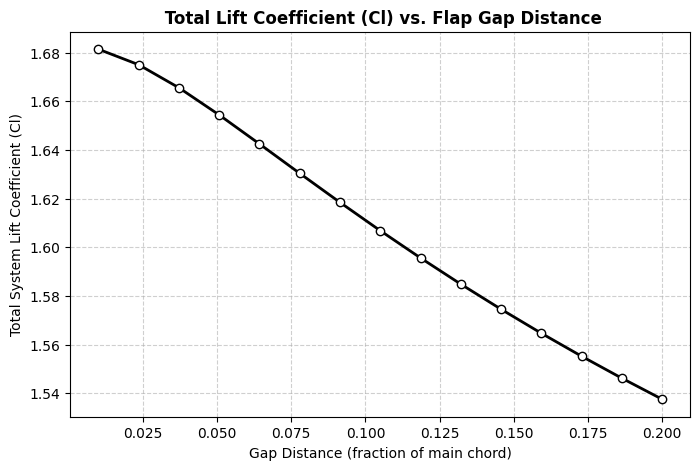

In [2]:
# ==========================================
# FIGURE 6: LIFT VS GAP DISTANCE
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

gap_distances = np.linspace(0.01, 0.20, 15)
total_Cl_values = []

c_main = 1.0
c_flap = 0.4
total_chord = c_main + c_flap

# Keep panel count reasonable for the loop to run fast
N_m = 40
N_f = 40
N_tot = N_m + N_f

# Re-build baseline main wing (doesn't change)
beta_m = np.linspace(0, 2*np.pi, N_m + 1)
x_m = 0.5 * (1 + np.cos(beta_m))
z_m = naca0015(x_m)
for i in range(len(beta_m)):
    if beta_m[i] < np.pi: z_m[i] = -z_m[i]

x_c_m, z_c_m = np.zeros(N_m), np.zeros(N_m)
nx_m, nz_m = np.zeros(N_m), np.zeros(N_m)
for i in range(N_m):
    x_c_m[i], z_c_m[i] = (x_m[i]+x_m[i+1])/2, (z_m[i]+z_m[i+1])/2
    dx, dz = x_m[i+1]-x_m[i], z_m[i+1]-z_m[i]
    L = np.sqrt(dx**2 + dz**2)
    nx_m[i], nz_m[i] = -dz/L, dx/L

# Local flap (doesn't change, only shifting changes)
beta_f = np.linspace(0, 2*np.pi, N_f + 1)
x_f_loc = 0.5 * c_flap * (1 + np.cos(beta_f))
z_f_loc = c_flap * naca0015(x_f_loc / c_flap)
for i in range(len(beta_f)):
    if beta_f[i] < np.pi: z_f_loc[i] = -z_f_loc[i]

for gap in gap_distances:
    shift_x = c_main + gap

    # Shift flap
    x_f = (x_f_loc * np.cos(flap_angle) - z_f_loc * np.sin(flap_angle)) + shift_x
    z_f = (x_f_loc * np.sin(flap_angle) + z_f_loc * np.cos(flap_angle)) + flap_shift_y

    x_c_f, z_c_f = np.zeros(N_f), np.zeros(N_f)
    nx_f, nz_f = np.zeros(N_f), np.zeros(N_f)
    for i in range(N_f):
        x_c_f[i], z_c_f[i] = (x_f[i]+x_f[i+1])/2, (z_f[i]+z_f[i+1])/2
        dx, dz = x_f[i+1]-x_f[i], z_f[i+1]-z_f[i]
        L = np.sqrt(dx**2 + dz**2)
        nx_f[i], nz_f[i] = -dz/L, dx/L

    # Combine geometry
    x_col_loop = np.concatenate([x_c_m, x_c_f])
    z_col_loop = np.concatenate([z_c_m, z_c_f])
    nx_loop = np.concatenate([nx_m, nx_f])
    nz_loop = np.concatenate([nz_m, nz_f])
    x_nodes_all = [x_m, x_f]
    z_nodes_all = [z_m, z_f]

    # Build Matrix
    A_loop = np.zeros((N_tot + 2, N_tot + 2))
    b_loop = np.zeros(N_tot + 2)

    for i in range(N_tot):
        b_loop[i] = -(U_inf * np.cos(alpha_wind) * nx_loop[i] + U_inf * np.sin(alpha_wind) * nz_loop[i])
        for wing_idx in (0, 1):
            offset = 0 if wing_idx == 0 else N_m
            nodes_x, nodes_z = x_nodes_all[wing_idx], z_nodes_all[wing_idx]
            for j in range(len(nodes_x)-1):
                u_L, w_L = point_vortex(x_col_loop[i], z_col_loop[i], nodes_x[j], nodes_z[j])
                u_R, w_R = point_vortex(x_col_loop[i], z_col_loop[i], nodes_x[j+1], nodes_z[j+1])
                A_loop[i, offset+j] = (-u_L + u_R)*nx_loop[i] + (-w_L + w_R)*nz_loop[i]

        # Wakes
        u_w1, w_w1 = point_vortex(x_col_loop[i], z_col_loop[i], x_m[0], z_m[0])
        A_loop[i, N_tot] = -u_w1*nx_loop[i] - w_w1*nz_loop[i]
        u_w2, w_w2 = point_vortex(x_col_loop[i], z_col_loop[i], x_f[0], z_f[0])
        A_loop[i, N_tot+1] = -u_w2*nx_loop[i] - w_w2*nz_loop[i]

    # Kutta
    A_loop[N_tot, 0], A_loop[N_tot, N_m-1], A_loop[N_tot, N_tot] = 1.0, -1.0, 1.0
    A_loop[N_tot+1, N_m], A_loop[N_tot+1, N_tot-1], A_loop[N_tot+1, N_tot+1] = 1.0, -1.0, 1.0

    mu_loop = np.linalg.solve(A_loop, b_loop)

    # Lift = Total Circulation
    total_circ = -mu_loop[N_tot] + -mu_loop[N_tot+1]
    Cl = (2.0 * total_circ) / (U_inf * total_chord)
    total_Cl_values.append(Cl)

plt.figure(figsize=(8, 5))
plt.plot(gap_distances, total_Cl_values, '-ok', linewidth=2, markerfacecolor='white')
plt.title(" Total Lift Coefficient (Cl) vs. Flap Gap Distance", fontweight='bold')
plt.xlabel("Gap Distance (fraction of main chord)")
plt.ylabel("Total System Lift Coefficient (Cl)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

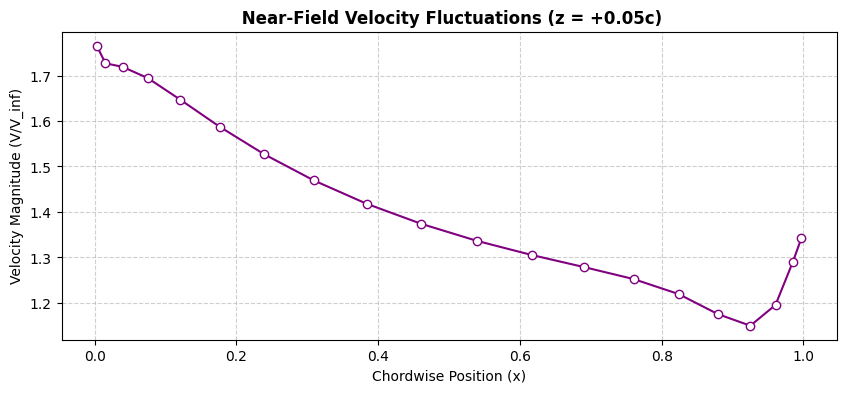

In [4]:
# ==========================================
# FIGURE 8: NEAR-FIELD WAVINESS
# ==========================================
# Get the top surface panels of the main wing
top_indices = range(N_main // 2, N_main)
x_test = x_col[top_indices]
z_test = z_col[top_indices] + 0.05  # Shift sensor up by 5% of chord

V_near_field = np.zeros_like(x_test)

for i in range(len(x_test)):
    u = U_inf * np.cos(alpha_wind)
    w = U_inf * np.sin(alpha_wind)

    # Sum influences from all main wing doublets
    for j in range(N_main):
        u_L, w_L = point_vortex(x_test[i], z_test[i], x_nodes_main[j], z_nodes_main[j])
        u_R, w_R = point_vortex(x_test[i], z_test[i], x_nodes_main[j+1], z_nodes_main[j+1])
        u += mu[j] * (-u_L + u_R)
        w += mu[j] * (-w_L + w_R)

    V_near_field[i] = np.sqrt(u**2 + w**2)

plt.figure(figsize=(10, 4))
plt.plot(x_test, V_near_field, '-o', color='purple', markerfacecolor='white')
plt.title(" Near-Field Velocity Fluctuations (z = +0.05c)", fontweight='bold')
plt.xlabel("Chordwise Position (x)")
plt.ylabel("Velocity Magnitude (V/V_inf)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

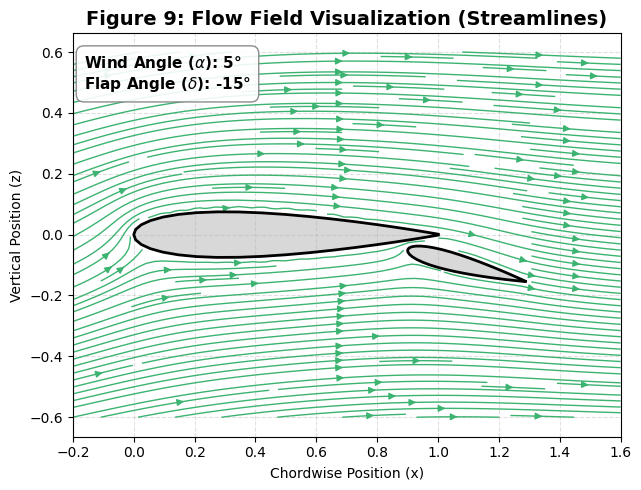

In [5]:
# ==========================================
# FIGURE 9: ISOLATED STREAMLINES
# ==========================================
plt.figure(figsize=(12, 5))

# Calculate flow grid
X, Z = np.meshgrid(np.linspace(-0.2, 1.6, 150), np.linspace(-0.6, 0.6, 100))
U = U_inf * np.cos(alpha_wind) * np.ones_like(X)
W = U_inf * np.sin(alpha_wind) * np.ones_like(Z)

# Main wing field
for j in range(N_main):
    dx_L, dz_L = X - x_nodes_main[j], Z - z_nodes_main[j]
    dx_R, dz_R = X - x_nodes_main[j+1], Z - z_nodes_main[j+1]
    r_L, r_R = np.maximum(dx_L**2 + dz_L**2, 1e-5), np.maximum(dx_R**2 + dz_R**2, 1e-5)
    U += mu[j] * (-(1/(2*np.pi))*(dz_L/r_L) + (1/(2*np.pi))*(dz_R/r_R))
    W += mu[j] * ((1/(2*np.pi))*(dx_L/r_L) - (1/(2*np.pi))*(dx_R/r_R))

# Flap field
for j in range(N_flap):
    idx = N_main + j
    dx_L, dz_L = X - x_nodes_flap[j], Z - z_nodes_flap[j]
    dx_R, dz_R = X - x_nodes_flap[j+1], Z - z_nodes_flap[j+1]
    r_L, r_R = np.maximum(dx_L**2 + dz_L**2, 1e-5), np.maximum(dx_R**2 + dz_R**2, 1e-5)
    U += mu[idx] * (-(1/(2*np.pi))*(dz_L/r_L) + (1/(2*np.pi))*(dz_R/r_R))
    W += mu[idx] * ((1/(2*np.pi))*(dx_L/r_L) - (1/(2*np.pi))*(dx_R/r_R))

# Wake Field
dx_W1, dz_W1 = X - x_nodes_main[0], Z - z_nodes_main[0]
r_W1 = np.maximum(dx_W1**2 + dz_W1**2, 1e-5)
U += (-mu[N_total]) * (1/(2*np.pi)) * (dz_W1 / r_W1)
W += (-mu[N_total]) * (-1/(2*np.pi)) * (dx_W1 / r_W1)

dx_W2, dz_W2 = X - x_nodes_flap[0], Z - z_nodes_flap[0]
r_W2 = np.maximum(dx_W2**2 + dz_W2**2, 1e-5)
U += (-mu[N_total + 1]) * (1/(2*np.pi)) * (dz_W2 / r_W2)
W += (-mu[N_total + 1]) * (-1/(2*np.pi)) * (dx_W2 / r_W2)

# Mask the metal interior
points = np.column_stack((X.flatten(), Z.flatten()))
main_path = Path(np.column_stack((x_nodes_main, z_nodes_main)))
flap_path = Path(np.column_stack((x_nodes_flap, z_nodes_flap)))
mask_2d = (main_path.contains_points(points) | flap_path.contains_points(points)).reshape(X.shape)
U[mask_2d] = np.nan
W[mask_2d] = np.nan

# Plotting
plt.streamplot(X, Z, U, W, density=2, color='mediumseagreen', linewidth=1, arrowsize=1)
plt.plot(x_nodes_main, z_nodes_main, '-k', linewidth=2)
plt.plot(x_nodes_flap, z_nodes_flap, '-k', linewidth=2)
plt.fill(x_nodes_main, z_nodes_main, color='gray', alpha=0.3)
plt.fill(x_nodes_flap, z_nodes_flap, color='gray', alpha=0.3)

# Info Box
flap_deg = round(np.degrees(flap_angle))
info_text = f"Wind Angle ($\\alpha$): {alpha_wind_deg}°\nFlap Angle ($\\delta$): {flap_deg}°"
plt.text(0.02, 0.95, info_text, transform=plt.gca().transAxes, fontsize=11, fontweight='bold',
         verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9))

plt.title("Figure 9: Flow Field Visualization (Streamlines)", fontsize=14, fontweight='bold')
plt.xlabel("Chordwise Position (x)")
plt.ylabel("Vertical Position (z)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6567/3816808740.py:69: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-s" (-> color='r'). The keyword argument will take precedence.
  plt.plot(alpha_wind_range, ld_ratios, 'r-s', color='orange', label='Efficiency ($L/D$)')


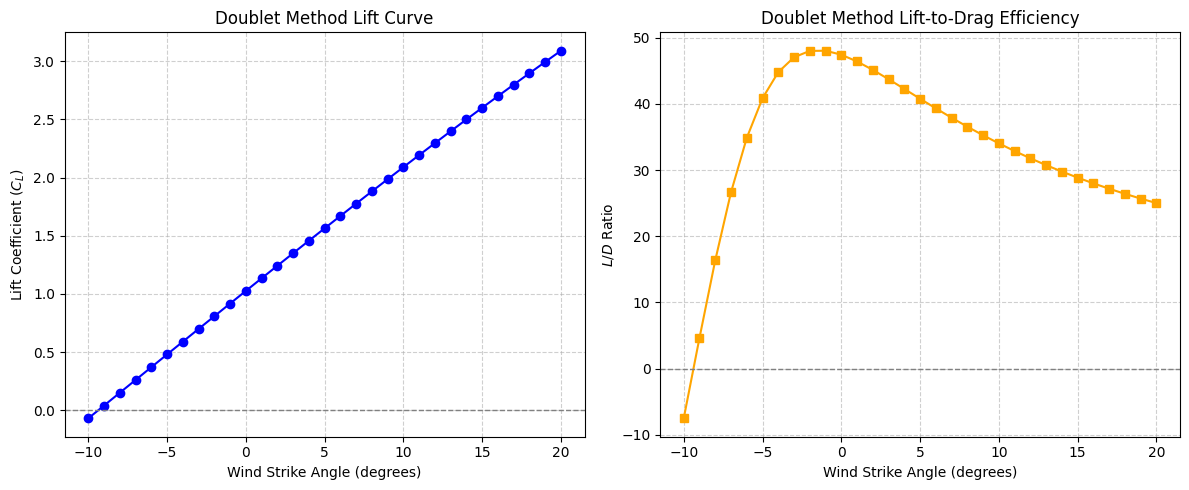

Maximum L/D ratio of 48.03 found at wind angle = -1.0 degrees


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
# Range of wind strike angles (alpha) to test
alpha_wind_range = np.linspace(-10, 20, 31) # from -10 to 20 degrees
cl_results = []
cd_results = []
ld_ratios = []

# Viscous Drag Parameters (Empirical corrections for real-world drag)
CD0 = 0.009  # Baseline skin friction drag coefficient
k = 0.012    # Drag factor that increases with lift (pressure drag)

# The total chord is the main wing (1.0) plus the flap chord
total_chord = 1.0 + flap_chord

# --- CALCULATION LOOP ---
for a_deg in alpha_wind_range:
    a_rad = np.radians(a_deg)

    # 1. Update Right Hand Side (b_loop) for the new wind angle
    # The Matrix A stays exactly the same, we only change the incoming wind vector
    b_loop = np.zeros(N_total + 2)
    for i in range(N_total):
        b_loop[i] = -(U_inf * np.cos(a_rad) * nx[i] + U_inf * np.sin(a_rad) * nz[i])

    # Kutta conditions at the trailing edges are always 0
    b_loop[N_total] = 0.0
    b_loop[N_total + 1] = 0.0

    # 2. Solve the linear system for Doublet Strengths (mu)
    mu_loop = np.linalg.solve(A, b_loop)

    # 3. Calculate Lift Coefficient (CL)
    # Using Kelvin's Theorem (Eq 11.42a): Lift is the negative of the wake doublet strength
    lift_main = -1.0 * mu_loop[N_total]
    lift_flap = -1.0 * mu_loop[N_total + 1]
    total_circ = lift_main + lift_flap

    # Non-dimensionalize to get Cl
    current_cl = (2.0 * total_circ) / (U_inf * total_chord)

    # 4. Calculate Empirical Drag Coefficient (CD)
    # Because doublet methods predict 0 drag, we add the profile drag manually
    current_cd = CD0 + k * (current_cl**2)

    # 5. Calculate L/D Ratio
    current_ld = current_cl / current_cd if current_cd != 0 else 0

    cl_results.append(current_cl)
    cd_results.append(current_cd)
    ld_ratios.append(current_ld)

# --- PLOTTING RESULTS ---
plt.figure(figsize=(12, 5))

# Subplot 1: Lift Polar (CL vs Alpha)
plt.subplot(1, 2, 1)
plt.plot(alpha_wind_range, cl_results, 'b-o', label='Lift ($C_L$)')
plt.axhline(0, color='gray', lw=1, linestyle='--')
plt.xlabel('Wind Strike Angle (degrees)')
plt.ylabel('Lift Coefficient ($C_L$)')
plt.title('Doublet Method Lift Curve')
plt.grid(True, linestyle='--', alpha=0.6)

# Subplot 2: Efficiency (L/D vs Alpha)
plt.subplot(1, 2, 2)
plt.plot(alpha_wind_range, ld_ratios, 'r-s', color='orange', label='Efficiency ($L/D$)')
plt.axhline(0, color='gray', lw=1, linestyle='--')
plt.xlabel('Wind Strike Angle (degrees)')
plt.ylabel('$L/D$ Ratio')
plt.title('Doublet Method Lift-to-Drag Efficiency')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Print the optimum angle
max_ld_idx = np.argmax(ld_ratios)
print(f"Maximum L/D ratio of {ld_ratios[max_ld_idx]:.2f} found at wind angle = {alpha_wind_range[max_ld_idx]:.1f} degrees")